# Tutorial 7: MOSTA FAST26 multi-section analysis

This executable tutorial displays compact inputs derived from the converged 2.32-million-position, 26-section, stage-grouped fit. Known developmental stages are sample labels used for partial pooling; they are not fitted pseudotime.

## Goal

Review the local preprocessing contract, display aligned molecular programs across three stages, inspect loading genes, and quantify loading-centre geometry without making a developmental trajectory claim.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='white', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
ASSET_DIR = next(path for path in [Path('_static/mosta_fast26_tutorial'), Path('source/_static/mosta_fast26_tutorial')] if path.exists())
summary = json.loads((ASSET_DIR / 'model_summary.json').read_text())
scores = pd.read_csv(ASSET_DIR / 'three_stage_program_scores.csv.gz')
summary

/Users/era/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


{'converged': True,
 'completed_iterations': 30,
 'rho': 0.20848641582341684,
 'eta': 0.005,
 'scale_reference': 41.69728316468337,
 'peak_rss_gb': 1.78521728515625,
 'n_cells': 2322560,
 'n_sections': 26,
 'n_genes': 2000,
 'n_components': 15,
 'group_column': 'stage',
 'n_groups': 5,
 'group_names': ['E12.5', 'E13.5', 'E14.5', 'E15.5', 'E16.5'],
 'mean_Ws_Wgroup_deviation': 1.7411338344241645,
 'max_Ws_Wgroup_deviation': 2.74347001879818,
 'mean_Wgroup_W0posthoc_deviation': 1.7111194126642701,
 'max_Wgroup_W0posthoc_deviation': 2.072169155417435,
 'convergence_mode': 'quotient_joint',
 'objective_tolerance': 1e-05,
 'z_tolerance': 0.001,
 'Ws_tolerance': 0.001,
 'W_groups_tolerance': 0.001,
 'joint_patience': 3,
 'plateau_parameter_multiplier': 5.0,
 'gauge_alignment_for_convergence': True,
 'gauge_mode': 'independent_groups',
 'gauge_component_count': 5,
 'convergence_rule': 'objective_plateau_with_bounded_group_aligned_change',
 'note': 'W0_posthoc is a reporting and orientation co

## 1. Local preprocessing and stage-aware fitting contract

The full workflow reads each FAST26 H5AD locally, uses raw `layers['count']`, performs library-size normalization and `log1p`, selects a stage-balanced 2,000-gene panel, constructs independent within-section graphs, and writes a disk-backed section store. The fit converged in 30 iterations on the complete atlas; it is not recomputed in this web tutorial.

In [2]:
RUN_FULL_ATLAS = False
if RUN_FULL_ATLAS:
    from pathlib import Path
    from GraphPCA import Run_Hierarchical_Multi_GPCA
    store_dir = Path('/path/to/MOSTA_section_store')
    output_dir = Path('/path/to/MOSTA_stage_grouped_fit')
    stage_labels = ['E12.5', 'E12.5']  # replace with all 26 manifest labels
    Z_disk, W_stage, Ws, info = Run_Hierarchical_Multi_GPCA(
        adatas=None, execution_mode='out_of_core', section_store=store_dir,
        out_of_core_output_dir=output_dir, out_of_core_group_labels=stage_labels,
        n_components=15, lambdas=0.5, rhos=0.20848642, max_iter=50, return_info=True)
    print(info.converged, info.n_iter)
else:
    print('Complete-atlas fit disabled; bundled assets come from the converged formal fit.')

Complete-atlas fit disabled; bundled assets come from the converged formal fit.


## 2. Spatially inspect aligned program coordinates

The scores below use the recorded stage alignment and common program rotation. Thus a given program label denotes one aligned loading coordinate across the displayed sections.

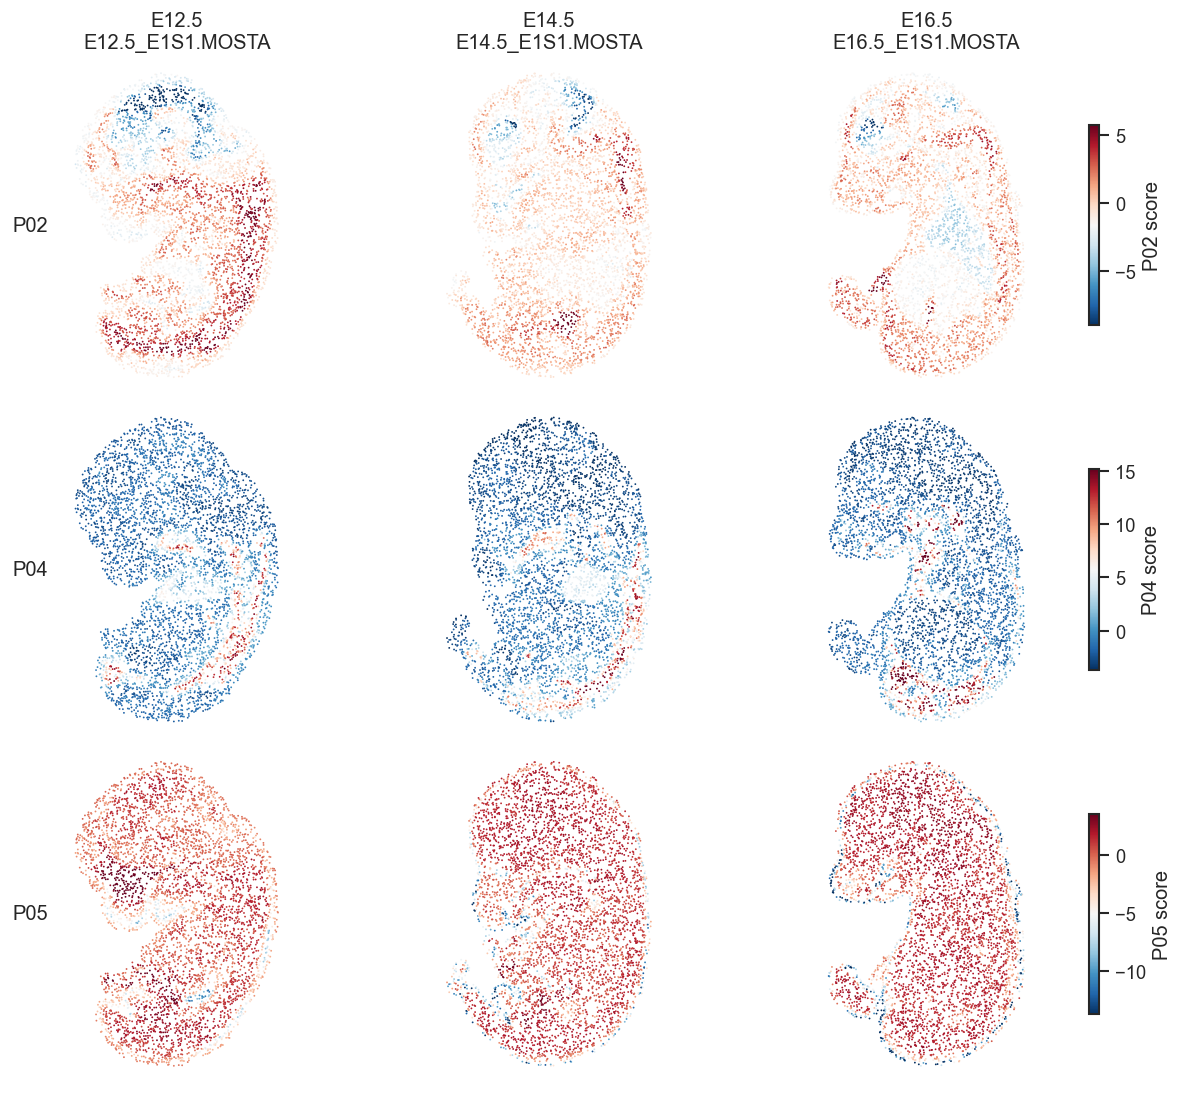

In [3]:
programs = ['P02', 'P04', 'P05']
sections = scores[['section', 'stage']].drop_duplicates().itertuples(index=False)
sections = list(sections)
fig, axes = plt.subplots(len(programs), len(sections), figsize=(10.5, 9), constrained_layout=True)
for row, program in enumerate(programs):
    lo, hi = scores[program].quantile([0.01, 0.99])
    for col, item in enumerate(sections):
        frame = scores.loc[scores.section.eq(item.section)]
        points = axes[row, col].scatter(frame.x, frame.y, c=frame[program], s=1.2, cmap='RdBu_r', vmin=lo, vmax=hi, linewidths=0, rasterized=True)
        axes[row, col].set(aspect='equal'); axes[row, col].invert_yaxis(); axes[row, col].axis('off')
        if row == 0: axes[row, col].set_title(f'{item.stage}\n{item.section}')
        if col == 0: axes[row, col].text(-0.08, .5, program, transform=axes[row, col].transAxes, ha='right', va='center')
    fig.colorbar(points, ax=axes[row, :], shrink=.6, label=f'{program} score')
plt.show()

## 3. Connect program labels to leading genes

The labels are post hoc summaries of aligned loading evidence. Annotation labels are not inputs to the factorization.

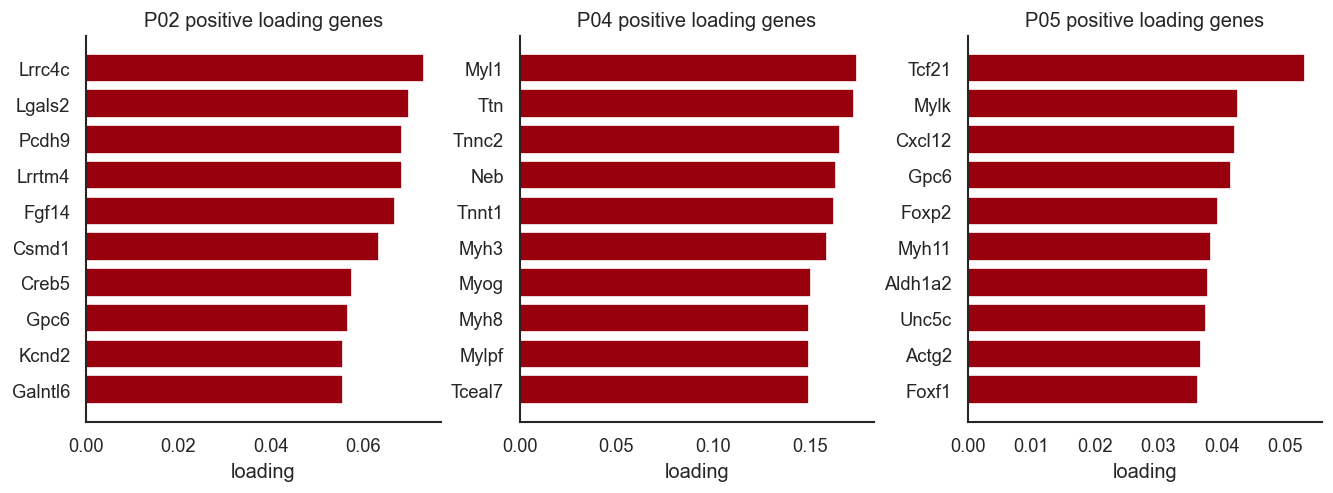

In [4]:
top_genes = pd.read_csv(ASSET_DIR / 'program_top_genes.csv')
fig, axes = plt.subplots(1, 3, figsize=(11, 4), constrained_layout=True)
for ax, program in zip(axes, programs):
    frame = top_genes.loc[top_genes.program.eq(program)].sort_values('loading')
    ax.barh(frame.gene, frame.loading, color='#99000D')
    ax.set_title(f'{program} positive loading genes'); ax.set_xlabel('loading')
plt.show()

## 4. Summarize aligned stage centres

This is a loading-space diagnostic: lower distances indicate more similar aligned stage centres. It is not a cell-level temporal trajectory or causal developmental analysis.

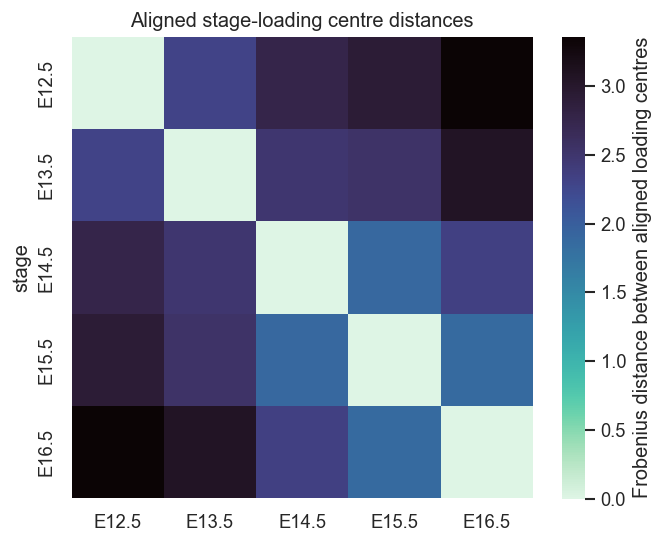

In [5]:
distance = pd.read_csv(ASSET_DIR / 'aligned_stage_loading_distances.csv').set_index('stage')
plt.figure(figsize=(6.2, 5))
sns.heatmap(distance, cmap='mako_r', square=True, cbar_kws={'label': 'Frobenius distance between aligned loading centres'})
plt.title('Aligned stage-loading centre distances')
plt.show()

## 5. Section-level score dispersion

The displayed standard deviations summarize heterogeneity within each section. They are grouped by known stage for visualization only and do not fit or assert pseudotime.

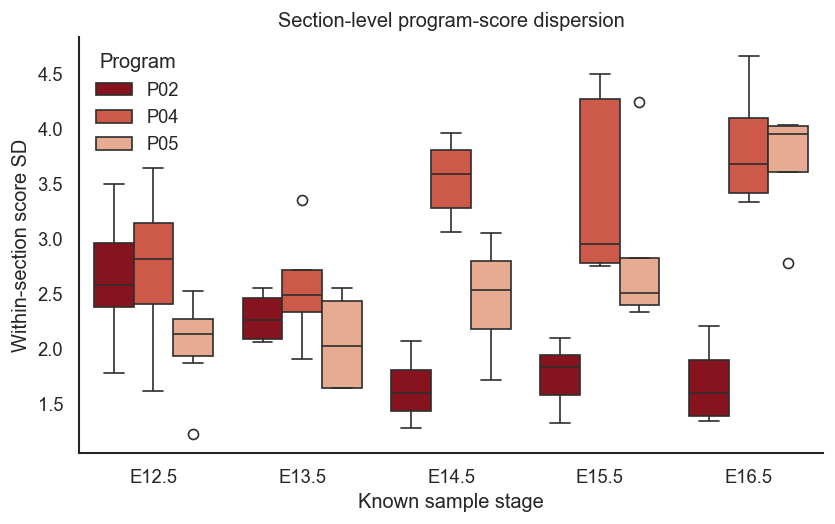

In [6]:
activity = pd.read_csv(ASSET_DIR / 'section_program_activity.csv')
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=activity, x='stage', y='sd', hue='program', palette=['#99000D', '#E34A33', '#F4A582'])
plt.xlabel('Known sample stage'); plt.ylabel('Within-section score SD'); plt.title('Section-level program-score dispersion')
plt.legend(title='Program', frameon=False)
plt.show()

## Checks and caveats

The bundled compact inputs are deterministic samples and tables from the converged formal stage-grouped fit (`n=2,322,560`, 26 sections, 2,000 genes). They are intended for visualization, not for recomputing the full atlas benchmark. This tutorial makes no P24 claim and does not report Monocle, Slingshot, pseudotime, or a causal developmental result.